In [1]:
# input
data = {
    "Group": ["WT", "WT", "H107A", "H107A"],
    "Metal": [ "Zn", "Ni", "Zn", "Ni"],
    "Data": [
        [0.358108, 0.285823],
        [0.019808, 0.016345], 
        [0.045236, 0.060265],
        [0.018265, 0.008712], 
    ]
}
# output
fig_file = "./fig/otcase_mutant_icp-mass.pdf"

[Text(0.125, 0, 'WT'), Text(1.125, 0, 'H107A')]

Text(0, 0.5, 'Ratio in mol (ion / protein)')

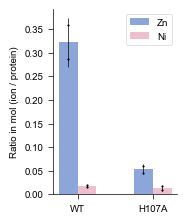

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

means = [np.mean(d) for d in data["Data"]]
stds = [np.std(d, ddof=1) for d in data["Data"]]

n_groups = 2  # WT, H107A
n_metals = 2  # Ni, Zn
bar_width = 0.25
group_spacing = 0.5
x = np.arange(n_groups) * (n_metals * bar_width + group_spacing)

fig, ax = plt.subplots(figsize=(1.6, 2.4))

for i in range(n_metals):
    bars = ax.bar(
        x + i * bar_width,
        means[i::n_metals],
        bar_width,
        label=data["Metal"][i],
        yerr=stds[i::n_metals],
    )
    
    for j, (bx, mean) in enumerate(zip(x + i * bar_width, means[i::n_metals])):
        ax.scatter(
            [bx] * 2,
            data["Data"][i + j * n_metals],
            color="black",
            s=1,
        )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(["WT", "H107A"])
ax.set_ylabel('Ratio in mol (ion / protein)')
ax.legend()
plt.savefig(fig_file, transparent=True, bbox_inches='tight')